In [3]:
import os 
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:

# ==========================================================
# PATHS
# ==========================================================
input_dir = r"D:\Nishka_Analysis\Analysis_Body_Wing\Data_DLC_DlTdv8\DLTdv8_Data\Final_DLTdv87_Data\Chase_CSVData\xyz_Smooth"

base_plot_dir = r"D:\Nishka_Analysis\Analysis_Body_Wing\Chase_Data"
base_csv_dir  = r"D:\Nishka_Analysis\Analysis_Body_Wing\Data_DLC_DlTdv8\DLTdv8_Data\Final_DLTdv87_Data\Chase_CSVData"

los_csv_dir = os.path.join(base_csv_dir, "line_of_sight")
os.makedirs(los_csv_dir, exist_ok=True)

# ==========================================================
# FIND FILES
# ==========================================================
csv_files = sorted(glob.glob(os.path.join(input_dir, "*_SMOOTH.csv")))
if not csv_files:
    raise FileNotFoundError("No *_SMOOTH.csv files found")

# ==========================================================
# PROCESS
# ==========================================================
for csv_path in csv_files:

    df = pd.read_csv(csv_path)

    base = os.path.splitext(os.path.basename(csv_path))[0]
    print("Processing:", base)

    # ------------------------------------------------------
    # Extract Trial + RPM 
    # ------------------------------------------------------
    m = re.search(r"(Trial\d+_\d+rpm)", base)
    if not m:
        raise ValueError(f"Could not extract Trial+RPM from filename: {base}")

    trial_name = m.group(1)

    # ------------------------------------------------------
    # Create plot directory
    # ------------------------------------------------------
    trial_plot_dir = os.path.join(base_plot_dir, trial_name)
    os.makedirs(trial_plot_dir, exist_ok=True)

    # ------------------------------------------------------
    # Extract points
    # ------------------------------------------------------
    head = df[["pt2_X", "pt2_Y", "pt2_Z"]].values
    bead = df[["pt1_X", "pt1_Y", "pt1_Z"]].values
    abdomen_tip = df[["pt7_X", "pt7_Y", "pt7_Z"]].values

    # Vectors
    v = bead - head           # head → bead
    u = head - abdomen_tip    # body axis

    # Distances
    d = np.linalg.norm(v, axis=1)
    p = np.linalg.norm(u, axis=1)

    valid = np.isfinite(d) & np.isfinite(p) & (d > 0) & (p > 0)

    v_hat = np.full_like(v, np.nan)
    u_hat = np.full_like(u, np.nan)

    v_hat[valid] = v[valid] / d[valid, None]
    u_hat[valid] = u[valid] / p[valid, None]

    # Angular error
    cos_theta = np.full_like(d, np.nan)
    cos_theta[valid] = np.sum(u_hat[valid] * v_hat[valid], axis=1)

    perpendicular = np.linalg.norm(np.cross(u_hat, v_hat), axis=1)

    theta = np.full_like(d, np.nan)
    theta[valid] = np.arctan2(perpendicular[valid], cos_theta[valid])
    theta_deg = np.degrees(theta)

    frames = df["frame"].values if "frame" in df.columns else np.arange(len(df))

    # ------------------------------------------------------
    # Line-of-sight geometry
    # ------------------------------------------------------
    c = 0.008  # bead diameter (m)
    r = c / 2

    alpha = np.full_like(d, np.nan)
    valid_alpha = valid & (d >= r)
    alpha[valid_alpha] = np.arctan(r / d[valid_alpha])


    cone_angle_deg = 2 * np.degrees(alpha)

    solid_angle_sr = np.full_like(alpha, np.nan)
    solid_angle_sr[valid_alpha] = 2 * np.pi * (1 - np.cos(alpha[valid_alpha]))
    solid_angle_deg2 = solid_angle_sr * (180 / np.pi) ** 2

    # ------------------------------------------------------
    # PLOTS
    # ------------------------------------------------------
    plt.figure(figsize=(8, 4))
    plt.plot(frames, theta_deg)
    plt.xlabel("Frame")
    plt.ylabel("Angular error (deg)")
    plt.title("Angular Error Over Time")
    plt.tight_layout()
    plt.savefig(os.path.join(trial_plot_dir, "angular_error_vs_frame.png"), dpi=300)
    plt.close()

    plt.figure(figsize=(8, 4))
    plt.plot(frames, cone_angle_deg)
    plt.xlabel("Frame")
    plt.ylabel("Cone opening angle (deg)")
    plt.title("Full LOS Cone Angle Over Time")
    plt.tight_layout()
    plt.savefig(os.path.join(trial_plot_dir, "cone_angle_vs_frame.png"), dpi=300)
    plt.close()

    plt.figure(figsize=(6, 4))
    plt.plot(d[valid_alpha], cone_angle_deg[valid_alpha])
    plt.gca().invert_xaxis()
    plt.xlabel("Distance to bead (m)")
    plt.ylabel("Cone opening angle (deg)")
    plt.title("LOS Cone Angle vs Distance")
    plt.tight_layout()
    plt.savefig(os.path.join(trial_plot_dir, "cone_angle_vs_distance.png"), dpi=300)
    plt.close()

    plt.figure(figsize=(8, 4))
    plt.plot(frames, solid_angle_deg2)
    plt.xlabel("Frame")
    plt.ylabel("Solid angle (deg²)")
    plt.title("3D Visual Solid Angle Over Time")
    plt.tight_layout()
    plt.savefig(os.path.join(trial_plot_dir, "solid_angle_vs_frame.png"), dpi=300)
    plt.close()

    # ------------------------------------------------------
    # SAVE NUMERIC DATA
    # ------------------------------------------------------
    out_df = pd.DataFrame({
        "frame": frames,
        "distance_to_bead_m": d,
        "angular_error_deg": theta_deg,
        "cone_angle_deg": cone_angle_deg,
        "solid_angle_sr": solid_angle_sr,
        "solid_angle_deg2": solid_angle_deg2
    })

    out_df.to_csv(
        os.path.join(los_csv_dir, f"{trial_name}_line_of_sight.csv"),
        index=False
    )

    print("Saved LOS data + plots for:", trial_name)

print("\n Line-of-sight analysis complete (trial + RPM safe).")


Processing: Final_DLTdv87_Data_DLTdv8_data_Trial2_180rpmxyzpts_SMOOTH
Saved LOS data + plots for: Trial2_180rpm
Processing: Final_DLTdv87_Data_DLTdv8_data_Trial2_200rpmxyzpts_SMOOTH
Saved LOS data + plots for: Trial2_200rpm
Processing: Final_DLTdv87_Data_DLTdv8_data_Trial3_180rpmxyzpts_SMOOTH
Saved LOS data + plots for: Trial3_180rpm
Processing: Final_DLTdv87_Data_DLTdv8_data_Trial4_400rpmxyzpts_SMOOTH
Saved LOS data + plots for: Trial4_400rpm
Processing: Final_DLTdv87_Data_DLTdv8_data_Trial5_180rpmxyzpts_SMOOTH
Saved LOS data + plots for: Trial5_180rpm
Processing: Final_DLTdv87_Data_DLTdv8_data_Trial5_400rpmxyzpts_SMOOTH
Saved LOS data + plots for: Trial5_400rpm
Processing: Final_DLTdv87_Data_DLTdv8_data_Trial7_400rpmxyzpts_SMOOTH
Saved LOS data + plots for: Trial7_400rpm

 Line-of-sight analysis complete (trial + RPM safe).


# Sanity check

Angular error (deg): 30.00
Cone angle (deg): 0.4584
Solid angle (deg²): 0.1650


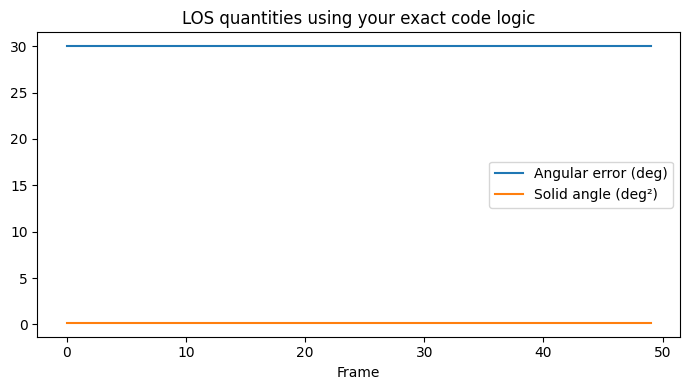

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Points (exactly one "frame")
# -----------------------------
head = np.array([[1.0, 0.0, 0.0]])
abdomen_tip = np.array([[0.0, 0.0, 0.0]])
bead = np.array([[1.866, 0.5, 0.0]])

# -----------------------------
# Vectors (your code)
# -----------------------------
v = bead - head            # head → bead
u = head - abdomen_tip     # body axis

# Distances
d = np.linalg.norm(v, axis=1)
p = np.linalg.norm(u, axis=1)

valid = (d > 0) & (p > 0)

v_hat = np.full_like(v, np.nan)
u_hat = np.full_like(u, np.nan)

v_hat[valid] = v[valid] / d[valid, None]
u_hat[valid] = u[valid] / p[valid, None]

# -----------------------------
# Angular error (your code)
# -----------------------------
cos_theta = np.full_like(d, np.nan)
cos_theta[valid] = np.sum(u_hat[valid] * v_hat[valid], axis=1)

perpendicular = np.linalg.norm(np.cross(u_hat, v_hat), axis=1)

theta = np.full_like(d, np.nan)
theta[valid] = np.arctan2(perpendicular[valid], cos_theta[valid])
theta_deg = np.degrees(theta)

print(f"Angular error (deg): {theta_deg[0]:.2f}")

# -----------------------------
# Solid angle (your code)
# -----------------------------
c = 0.008
r = c / 2

alpha = np.full_like(d, np.nan)
valid_alpha = valid & (d >= r)
alpha[valid_alpha] = np.arctan(r / d[valid_alpha])

cone_angle_deg = 2 * np.degrees(alpha)

solid_angle_sr = np.full_like(alpha, np.nan)
solid_angle_sr[valid_alpha] = 2 * np.pi * (1 - np.cos(alpha[valid_alpha]))
solid_angle_deg2 = solid_angle_sr * (180 / np.pi) ** 2

print(f"Cone angle (deg): {cone_angle_deg[0]:.4f}")
print(f"Solid angle (deg²): {solid_angle_deg2[0]:.4f}")

# -----------------------------
# One plot (flat lines)
# -----------------------------
frames = np.arange(50)

plt.figure(figsize=(7,4))
plt.plot(frames, np.ones_like(frames)*theta_deg[0], label="Angular error (deg)")
plt.plot(frames, np.ones_like(frames)*solid_angle_deg2[0], label="Solid angle (deg²)")
plt.xlabel("Frame")
plt.legend()
plt.title("LOS quantities using your exact code logic")
plt.tight_layout()
plt.show()


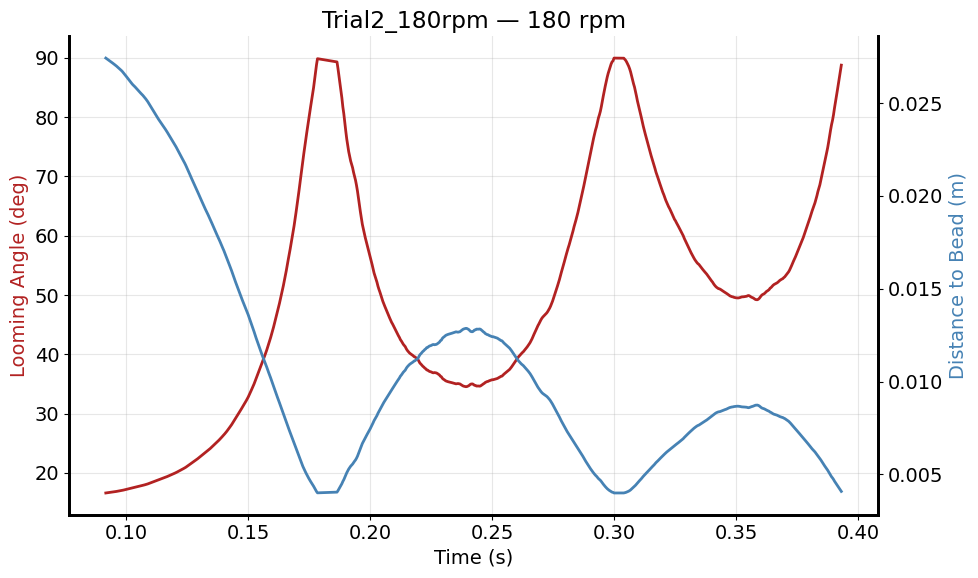

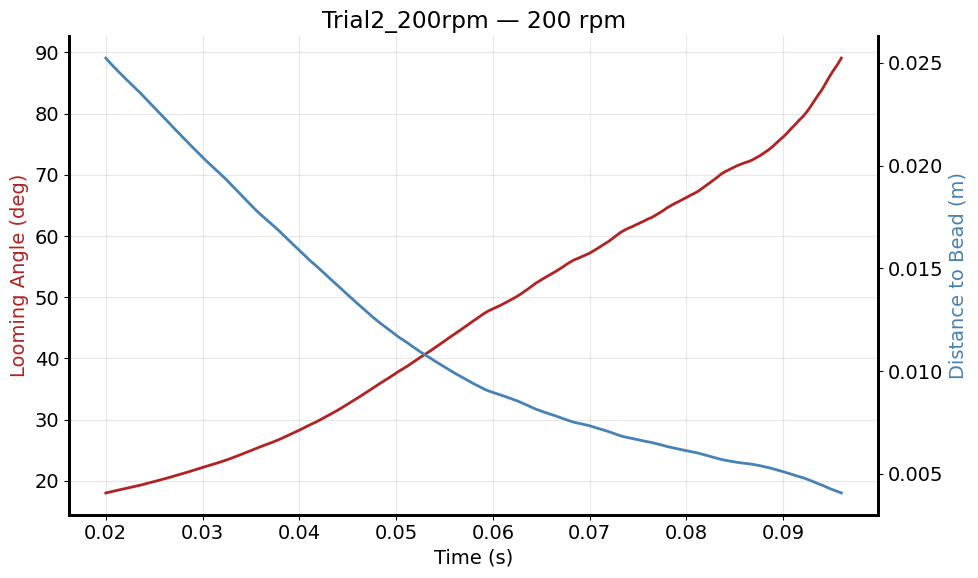

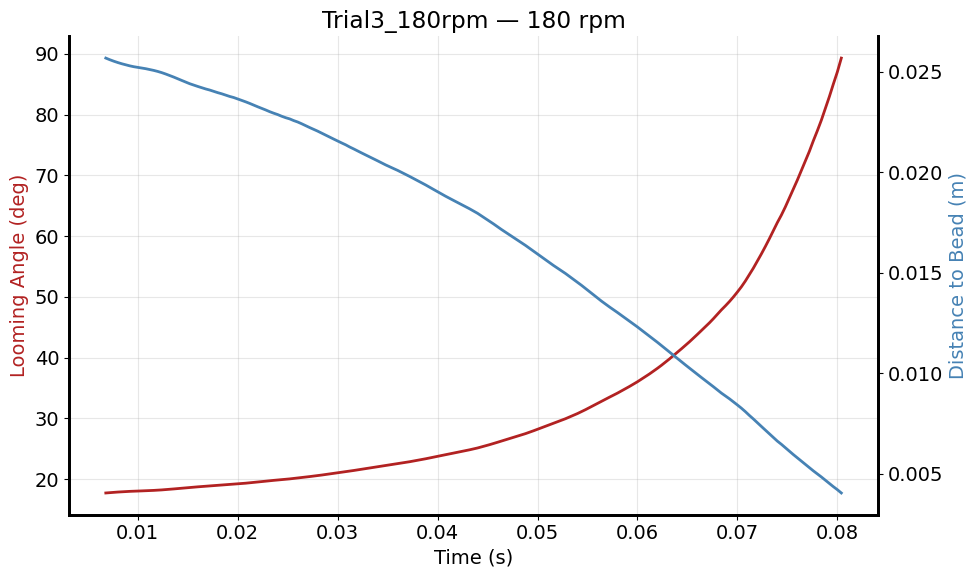

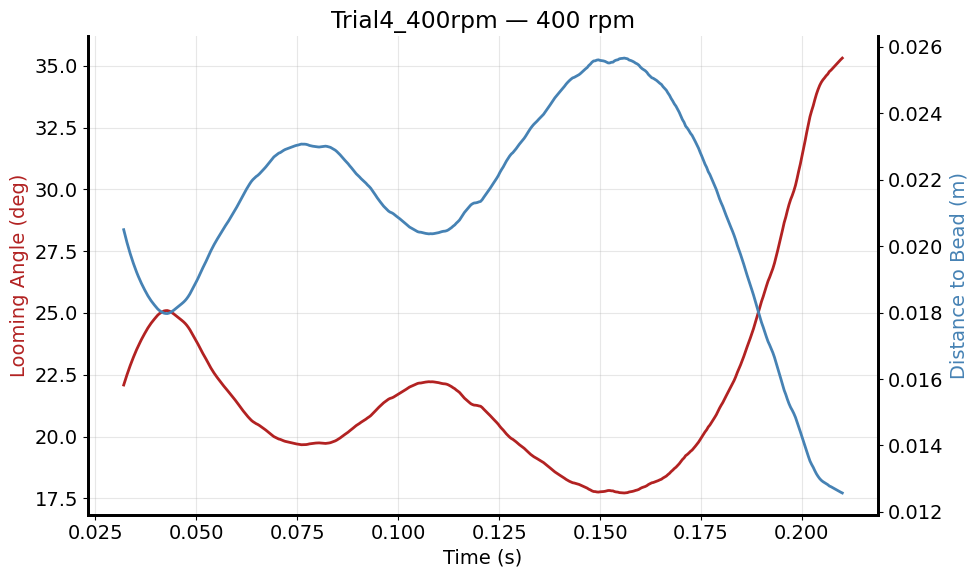

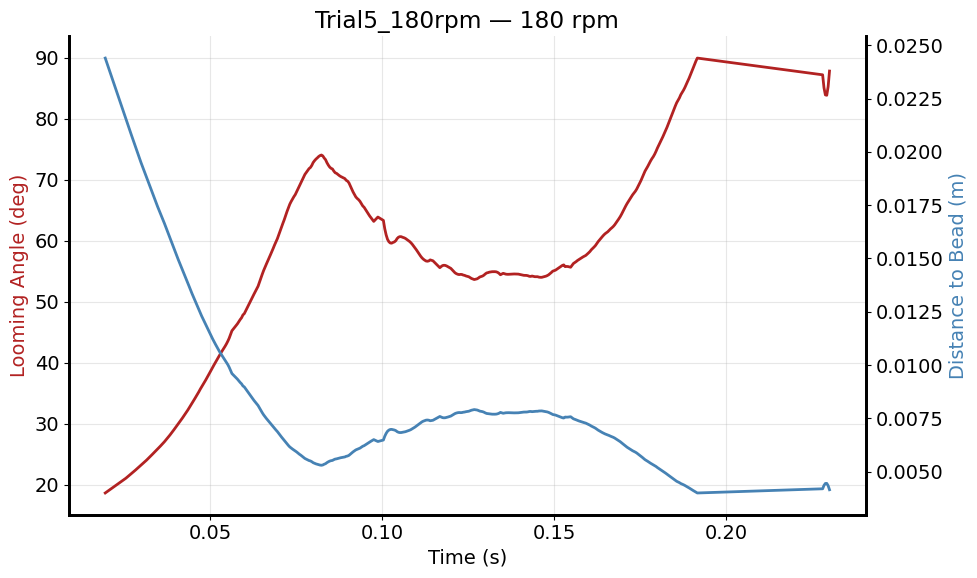

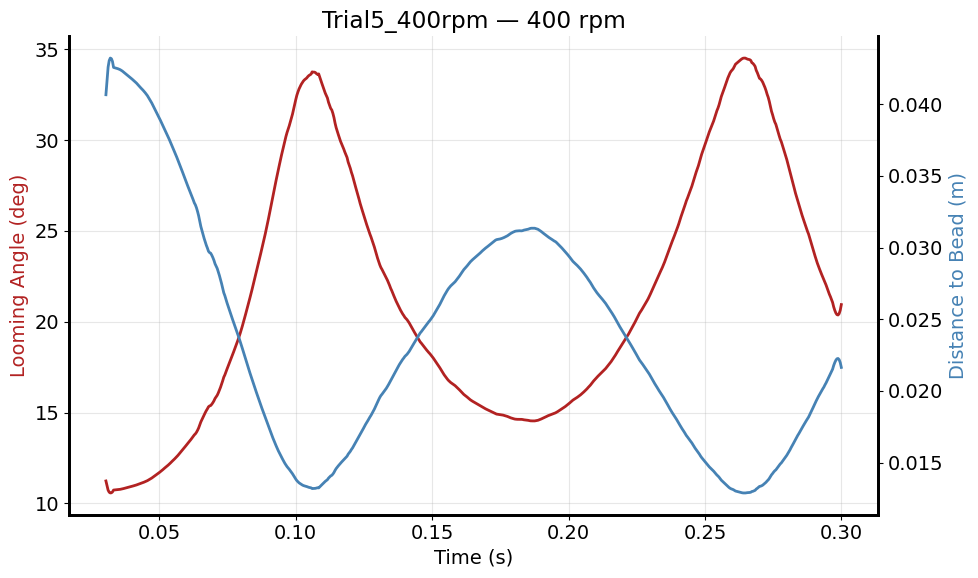

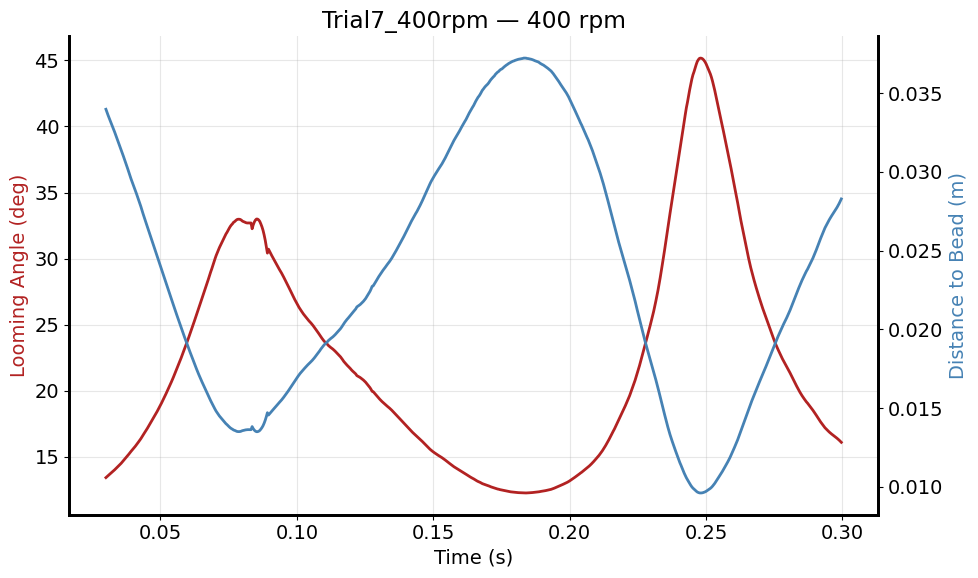

In [2]:
# ==========================================================
# IMPORTS
# ==========================================================
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# PATH
# ==========================================================
LOS_DIR = r"D:\Nishka_Analysis\Analysis_Body_Wing\Data_DLC_DlTdv8\DLTdv8_Data\Final_DLTdv87_Data\Chase_CSVData\line_of_sight"

FPS = 2500

# ==========================================================
# PLOT STYLE
# ==========================================================
plt.rcParams.update({
    "font.size": 14,
    "axes.linewidth": 2
})

# ==========================================================
# LOAD FILES
# ==========================================================
los_files = sorted(glob.glob(os.path.join(LOS_DIR, "*.csv")))

for lpath in los_files:

    name = os.path.basename(lpath)

    m = re.search(r"(Trial\d+_\d+rpm)", name)
    r = re.search(r"(\d+)rpm", name)

    if not m or not r:
        continue

    trial_id = m.group(1)
    rpm = int(r.group(1))

    df = pd.read_csv(lpath)

    df = df.dropna(subset=["cone_angle_deg","distance_to_bead_m"])

    time = df["frame"] / FPS
    looming = df["cone_angle_deg"]
    distance = df["distance_to_bead_m"]

    # ======================================================
    # CREATE PLOT
    # ======================================================
    fig, ax1 = plt.subplots(figsize=(10,6))

    ax2 = ax1.twinx()

    # looming angle
    ax1.plot(time, looming, color="firebrick", linewidth=2, label="Looming Angle")

    # distance
    ax2.plot(time, distance, color="steelblue", linewidth=2, label="Distance to Bead")

    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Looming Angle (deg)", color="firebrick")
    ax2.set_ylabel("Distance to Bead (m)", color="steelblue")

    ax1.set_title(f"{trial_id} — {rpm} rpm")

    ax1.grid(alpha=0.3)

    ax1.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)

    plt.tight_layout()
    plt.show()

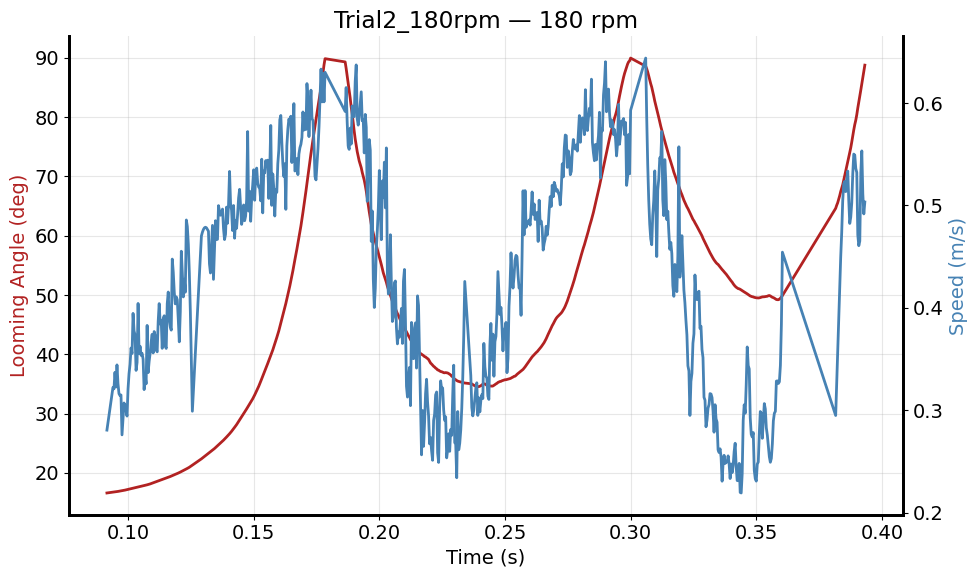

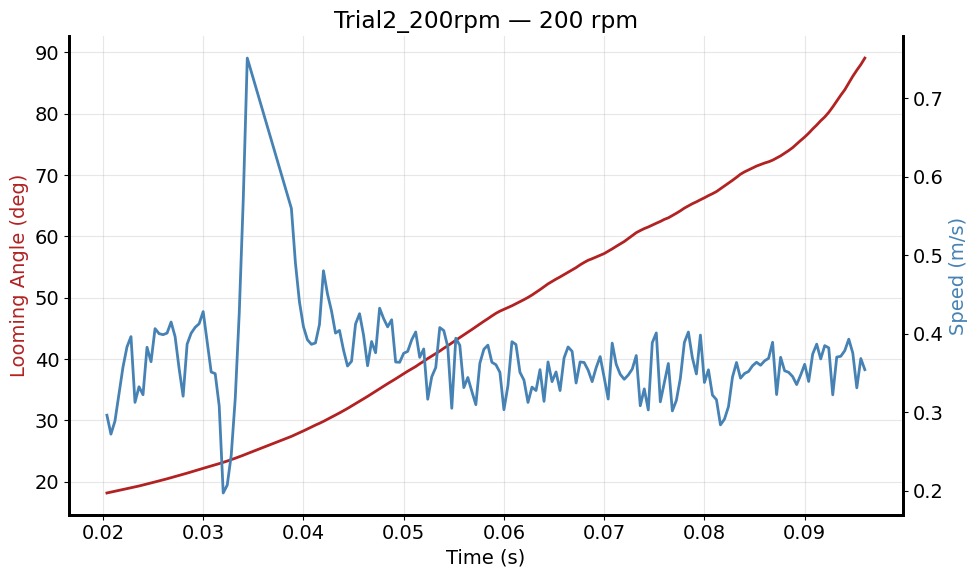

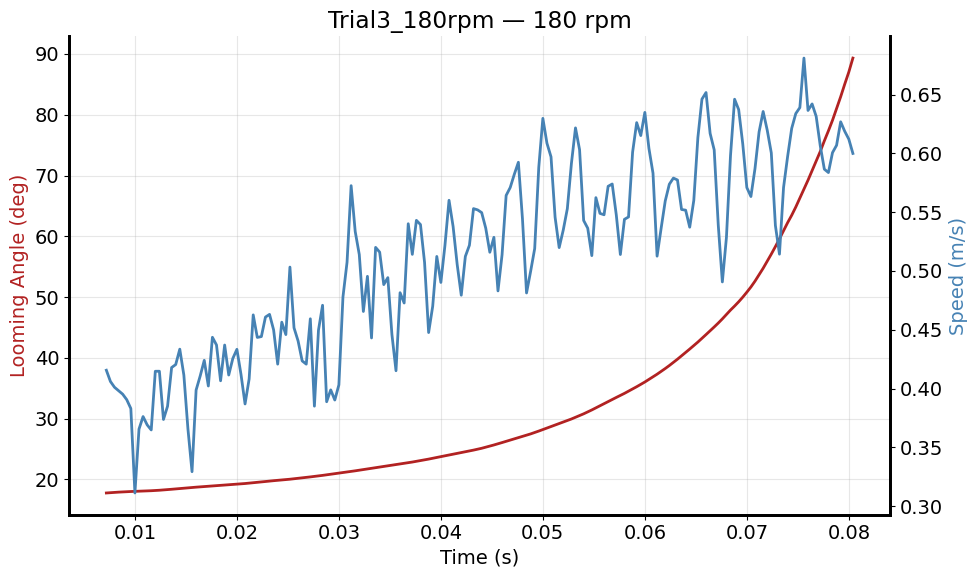

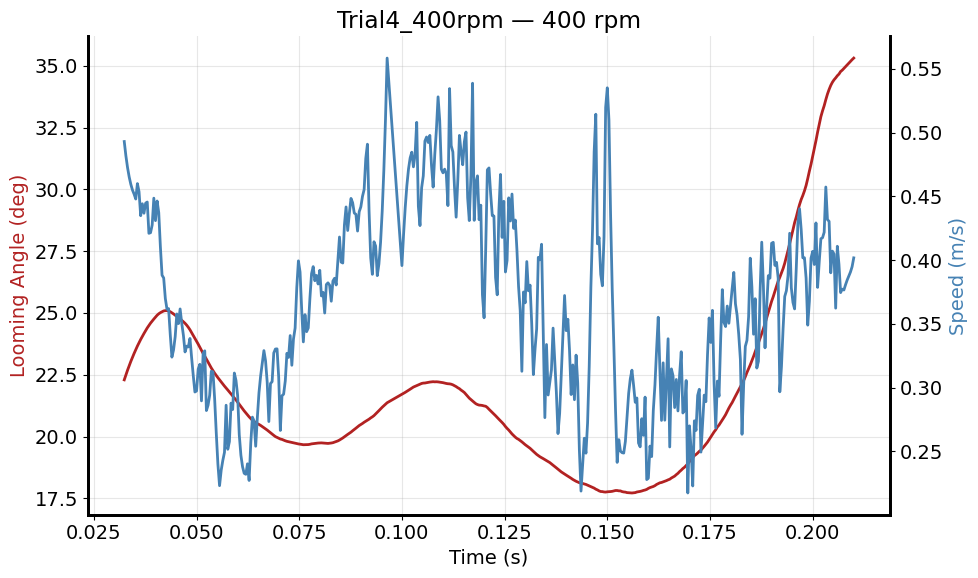

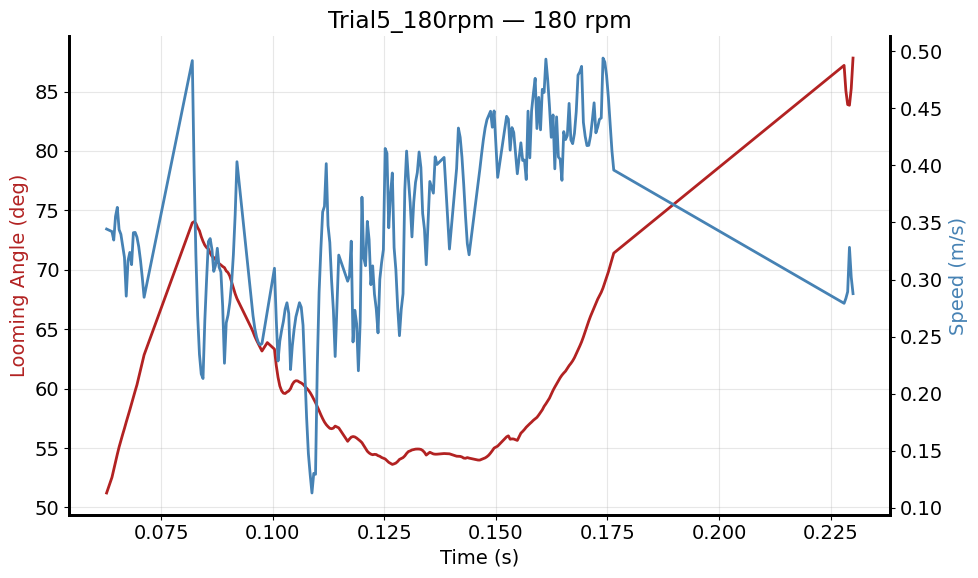

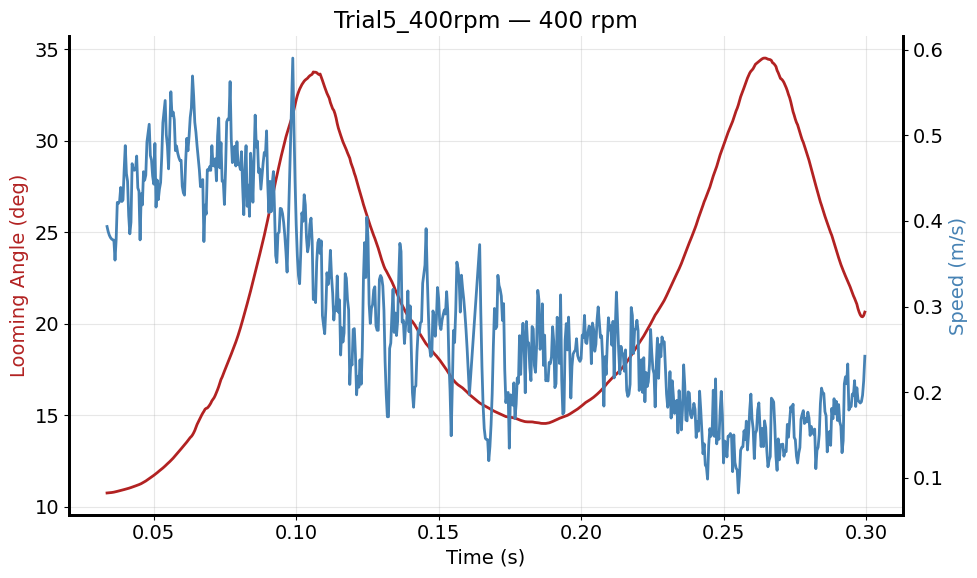

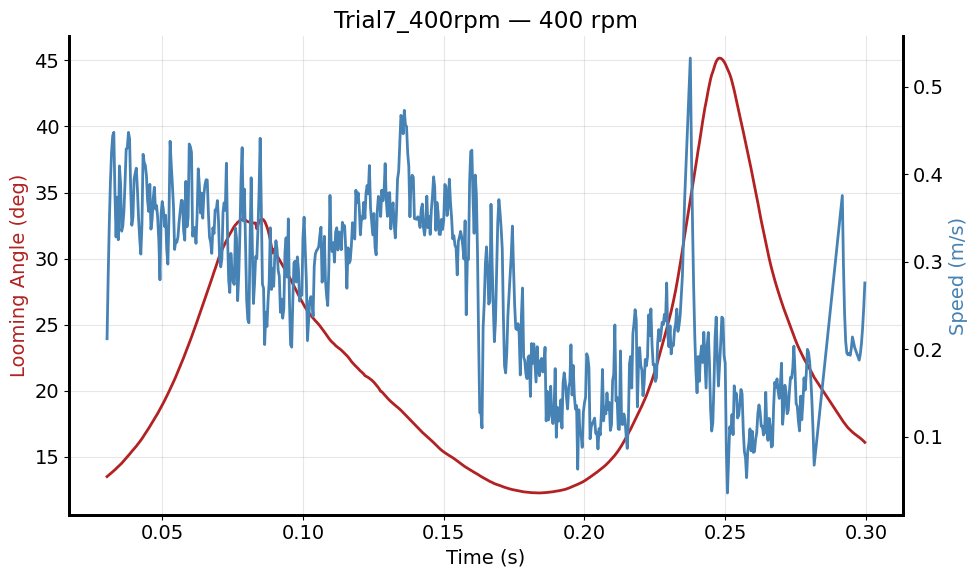

In [3]:
# ==========================================================
# IMPORTS
# ==========================================================
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# PATHS
# ==========================================================
LOS_DIR   = r"D:\Nishka_Analysis\Analysis_Body_Wing\Data_DLC_DlTdv8\DLTdv8_Data\Final_DLTdv87_Data\Chase_CSVData\line_of_sight"
SPEED_DIR = r"D:\Nishka_Analysis\Analysis_Body_Wing\Data_DLC_DlTdv8\DLTdv8_Data\Final_DLTdv87_Data\Chase_CSVData\Speed"

FPS = 2500

# ==========================================================
# PLOT STYLE
# ==========================================================
plt.rcParams.update({
    "font.size": 14,
    "axes.linewidth": 2
})

# ==========================================================
# LOAD FILES
# ==========================================================
speed_files = sorted(glob.glob(os.path.join(SPEED_DIR, "*.csv")))

for spath in speed_files:

    name = os.path.basename(spath)

    m = re.search(r"(Trial\d+_\d+rpm)", name)
    r = re.search(r"(\d+)rpm", name)

    if not m or not r:
        continue

    trial_id = m.group(1)
    rpm = int(r.group(1))

    los_matches = glob.glob(os.path.join(LOS_DIR, f"*{trial_id}*.csv"))

    if not los_matches:
        print(f"No LOS file for {trial_id}")
        continue

    df_speed = pd.read_csv(spath)
    df_los   = pd.read_csv(los_matches[0])

    # ======================================================
    # MERGE DATA
    # ======================================================
    df = pd.merge(
        df_speed[["frame","speed_m_per_s"]],
        df_los[["frame","cone_angle_deg"]],
        on="frame",
        how="inner"
    )

    df = df.dropna()

    time = df["frame"] / FPS
    speed = df["speed_m_per_s"]
    looming = df["cone_angle_deg"]

    # ======================================================
    # CREATE PLOT
    # ======================================================
    fig, ax1 = plt.subplots(figsize=(10,6))

    ax2 = ax1.twinx()

    ax1.plot(time, looming, color="firebrick", linewidth=2, label="Looming Angle")
    ax2.plot(time, speed, color="steelblue", linewidth=2, label="Speed")

    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Looming Angle (deg)", color="firebrick")
    ax2.set_ylabel("Speed (m/s)", color="steelblue")

    ax1.set_title(f"{trial_id} — {rpm} rpm")

    ax1.grid(alpha=0.3)

    ax1.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)

    plt.tight_layout()
    plt.show()